In [2]:
# --- 1. Imports & Setup ---
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import importlib

# AllenSDK
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Analysis & TDA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import umap
from ripser import ripser
from persim import plot_diagrams

# Visualization
import networkx as nx
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Custom Style
import viz_style
importlib.reload(viz_style) # Reload to ensure latest changes are applied
viz_style.set_architectural_style()

print("Libraries imported and Architectural Style applied.")

Architectural plot style applied (Dark Mode).
Libraries imported and Architectural Style applied.


In [3]:
# --- 2. Data Loading ---
output_dir = "../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

session_id = 750749662
print(f"Loading Session {session_id}...")
session = cache.get_session_data(session_id)

# Load Movie Template
print("Loading Natural Movie One Template...")
movie_template = cache.get_natural_movie_template(1)
print(f"Movie Template Shape: {movie_template.shape}")

Loading Session 750749662...


/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Loading Natural Movie One Template...
Movie Template Shape: (900, 304, 608)


In [ ]:
# --- 3. Define Analysis Pipeline Function ---

def run_tda_pipeline(session, region_acronym, movie_template):
    print(f"\n{'='*40}")
    print(f"STARTING ANALYSIS FOR REGION: {region_acronym}")
    print(f"{'='*40}")
    
    # 1. Filter Units
    region_units = session.units[session.units["ecephys_structure_acronym"] == region_acronym]
    n_units = len(region_units)
    print(f"Found {n_units} units in {region_acronym}")
    
    if n_units < 10:
        print(f"Skipping {region_acronym}: Not enough units (<10).")
        return

    # 2. Construct Neural Response Matrix
    movie_table = session.get_stimulus_table("natural_movie_one")
    frame_duration = movie_table['duration'].mean()

    print("Calculating spike counts...")
    spike_counts_xr = session.presentationwise_spike_counts(
        stimulus_presentation_ids=movie_table.index.values,
        bin_edges=np.array([0, frame_duration]),
        unit_ids=region_units.index.values
    )

    response_matrix_all = spike_counts_xr.sum(dim="time_relative_to_stimulus_onset")
    
    df_response = pd.DataFrame(
        response_matrix_all.values,
        index=movie_table.index,
        columns=region_units.index
    )
    df_response['frame'] = movie_table['frame']
    average_response_matrix = df_response.groupby('frame').mean()
    X = average_response_matrix.values
    
    # 3. PCA & UMAP
    print("Running PCA & UMAP...")
    n_components_pca = min(50, n_units) # Adjust PCA components if units < 50
    pca = PCA(n_components=n_components_pca)
    X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
    
    reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
    embedding_3d = reducer.fit_transform(X_pca)
    
    # Plot UMAP
    fig = plt.figure(figsize=(10, 8))
    fig.patch.set_facecolor(viz_style.BLACK) # Force black background
    ax = fig.add_subplot(111, projection='3d')
    viz_style.plot_3d_trajectory(
        ax,
        embedding_3d[:, 0], embedding_3d[:, 1], embedding_3d[:, 2],
        c=np.arange(len(embedding_3d)),
        cmap='turbo',
        title=f"3D UMAP: {region_acronym}",
        xlabel="UMAP 1", ylabel="UMAP 2", zlabel="UMAP 3"
    )
    plt.show()
    
    # 4. TDA (Ripser)
    print("Running Persistent Homology...")
    result = ripser(X_pca, maxdim=2)
    diagrams = result['dgms']
    
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor(viz_style.BLACK) # Force black background
    ax.set_facecolor(viz_style.BLACK) # Force axis background
    
    plot_diagrams(diagrams, show=False, ax=ax)
    viz_style.format_axis(ax, title=f"Persistence Diagram ({region_acronym})", xlabel="Birth", ylabel="Death")
    ax.plot([0, 1], [0, 1], transform=ax.transAxes, color=viz_style.GRAY, linestyle="--")
    plt.show()
    
    # 5. Cluster Transition Network
    print("Building Transition Network...")
    n_states = 10
    kmeans = KMeans(n_clusters=n_states, random_state=42, n_init=10)
    state_labels = kmeans.fit_predict(X_pca)
    
    transition_matrix = np.zeros((n_states, n_states))
    for t in range(len(state_labels) - 1):
        current_state = state_labels[t]
        next_state = state_labels[t+1]
        transition_matrix[current_state, next_state] += 1
        
    row_sums = transition_matrix.sum(axis=1)
    transition_probs = np.divide(transition_matrix, row_sums[:, np.newaxis], 
                                 out=np.zeros_like(transition_matrix), 
                                 where=row_sums[:, np.newaxis]!=0)
                                 
    G_trans = nx.DiGraph()
    for i in range(n_states):
        count = np.sum(state_labels == i)
        G_trans.add_node(i, size=count)
        
    threshold = 0.1
    for i in range(n_states):
        for j in range(n_states):
            if i != j and transition_probs[i, j] > threshold:
                G_trans.add_edge(i, j, weight=transition_probs[i, j])
                
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor(viz_style.BLACK)
    ax.set_facecolor(viz_style.BLACK)
    
    pos_trans = nx.spring_layout(G_trans, k=1.5, seed=42)
    node_sizes = [G_trans.nodes[i]['size'] * 2 for i in G_trans.nodes]
    edges = G_trans.edges()
    weights = [G_trans[u][v]['weight'] * 5 for u, v in edges]
    
    viz_style.plot_network_graph(
        ax, G_trans, pos_trans, 
        node_colors=viz_style.CYAN, 
        node_size=node_sizes,
        edge_width=weights,
        with_labels=True,
        label_font_size=12,
        title=f"TRANSITION NETWORK: {region_acronym}"
    )
    plt.show()
    
    # 6. Spanning Tree & Image Overlay
    print("Building Spanning Tree & Visualizing...")
    # kNN Graph
    k_all = 10
    nbrs_all = NearestNeighbors(n_neighbors=k_all + 1).fit(embedding_3d)
    dists_all, inds_all = nbrs_all.kneighbors(embedding_3d)

    G_all = nx.Graph()
    num_all = embedding_3d.shape[0]
    G_all.add_nodes_from(range(num_all))

    for i in range(num_all):
        for d, j in zip(dists_all[i][1:], inds_all[i][1:]):
            G_all.add_edge(i, j, weight=float(d))

    T_all_full = nx.minimum_spanning_tree(G_all, weight="weight")

    if not nx.is_connected(T_all_full):
        largest_cc_all = max(nx.connected_components(T_all_full), key=len)
        T_all = T_all_full.subgraph(largest_cc_all).copy()
    else:
        T_all = T_all_full
        
    # Layout
    try:
        pos_all = nx.kamada_kawai_layout(T_all, scale=2.0)
    except:
        pos_all = nx.spring_layout(T_all, k=0.1, iterations=50, seed=42)
        
    # Identify Branch/Leaf
    degrees_all = dict(T_all.degree())
    branch_nodes_all = [n for n, deg in degrees_all.items() if deg >= 3]
    leaf_nodes_all = [n for n, deg in degrees_all.items() if deg == 1]
    
    frames_all = average_response_matrix.index.values
    
    # Calculate Node Colors based on Frame Index
    nodelist = list(T_all.nodes())
    node_colors = [frames_all[n] for n in nodelist]
    
    # Plot with Images
    fig, ax = plt.subplots(figsize=(24, 16))
    fig.patch.set_facecolor(viz_style.BLACK)
    ax.set_facecolor(viz_style.BLACK)

    viz_style.plot_network_with_images(
        ax, T_all, pos_all, 
        frames=frames_all,
        movie_template=movie_template,
        branch_nodes=branch_nodes_all,
        leaf_nodes=leaf_nodes_all,
        node_colors=node_colors, # Pass the calculated colors
        title=f"NEURAL MANIFOLD SKELETON: {region_acronym}"
    )
    
    # Add Colorbar
    norm = plt.Normalize(vmin=np.min(frames_all), vmax=np.max(frames_all))
    cmap = plt.cm.turbo
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01)
    cbar.set_label("FRAME INDEX (TIME)", fontsize=14, color=viz_style.WHITE)
    cbar.ax.yaxis.label.set_color(viz_style.WHITE)
    cbar.ax.tick_params(colors=viz_style.WHITE)
    cbar.outline.set_visible(False)
    
    plt.show()
    print(f"Finished analysis for {region_acronym}")

/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Available Regions: ['Eth' 'PO' 'LP' 'DG' 'CA1' 'VISam' 'LD' 'VISpm' 'VISp' 'CA3' 'VISl' 'VPM'
 'TH' 'LGd' 'VISal' 'VISrl']

STARTING ANALYSIS FOR REGION: Eth
Found 2 units in Eth
Skipping Eth: Not enough units (<10).

STARTING ANALYSIS FOR REGION: PO
Found 30 units in PO


/opt/anaconda3/envs/TDA/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Calculating spike counts...
Running PCA & UMAP...


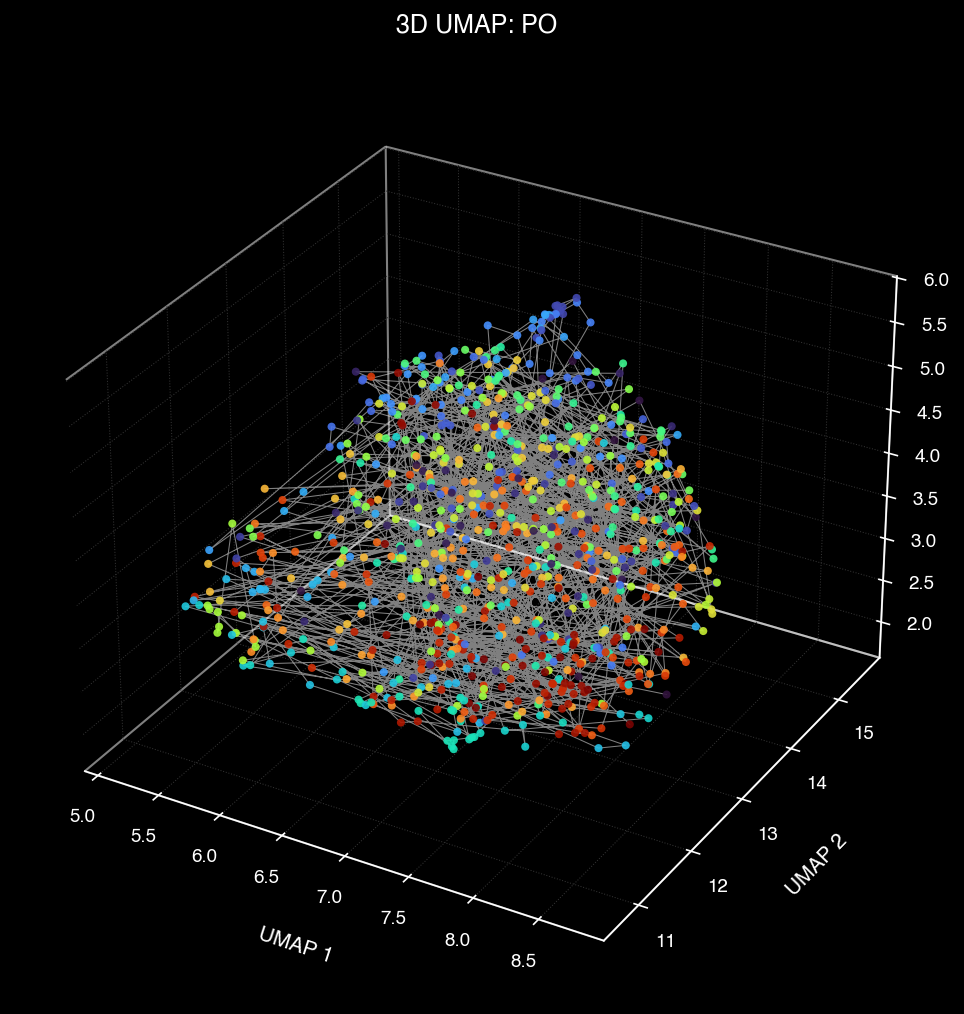

Running Persistent Homology...


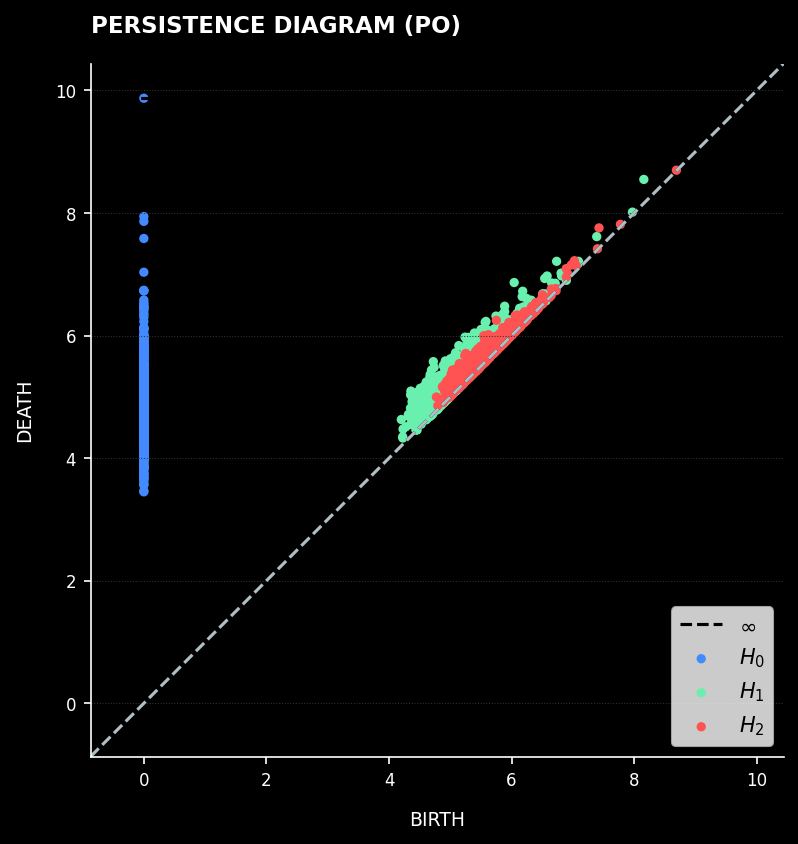

Building Transition Network...


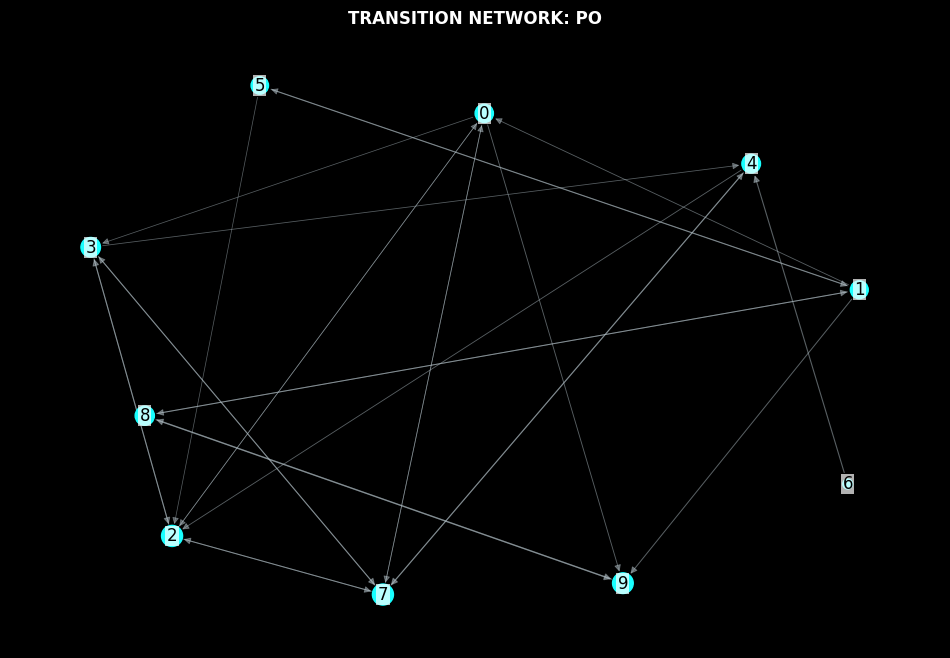

Building Spanning Tree & Visualizing...


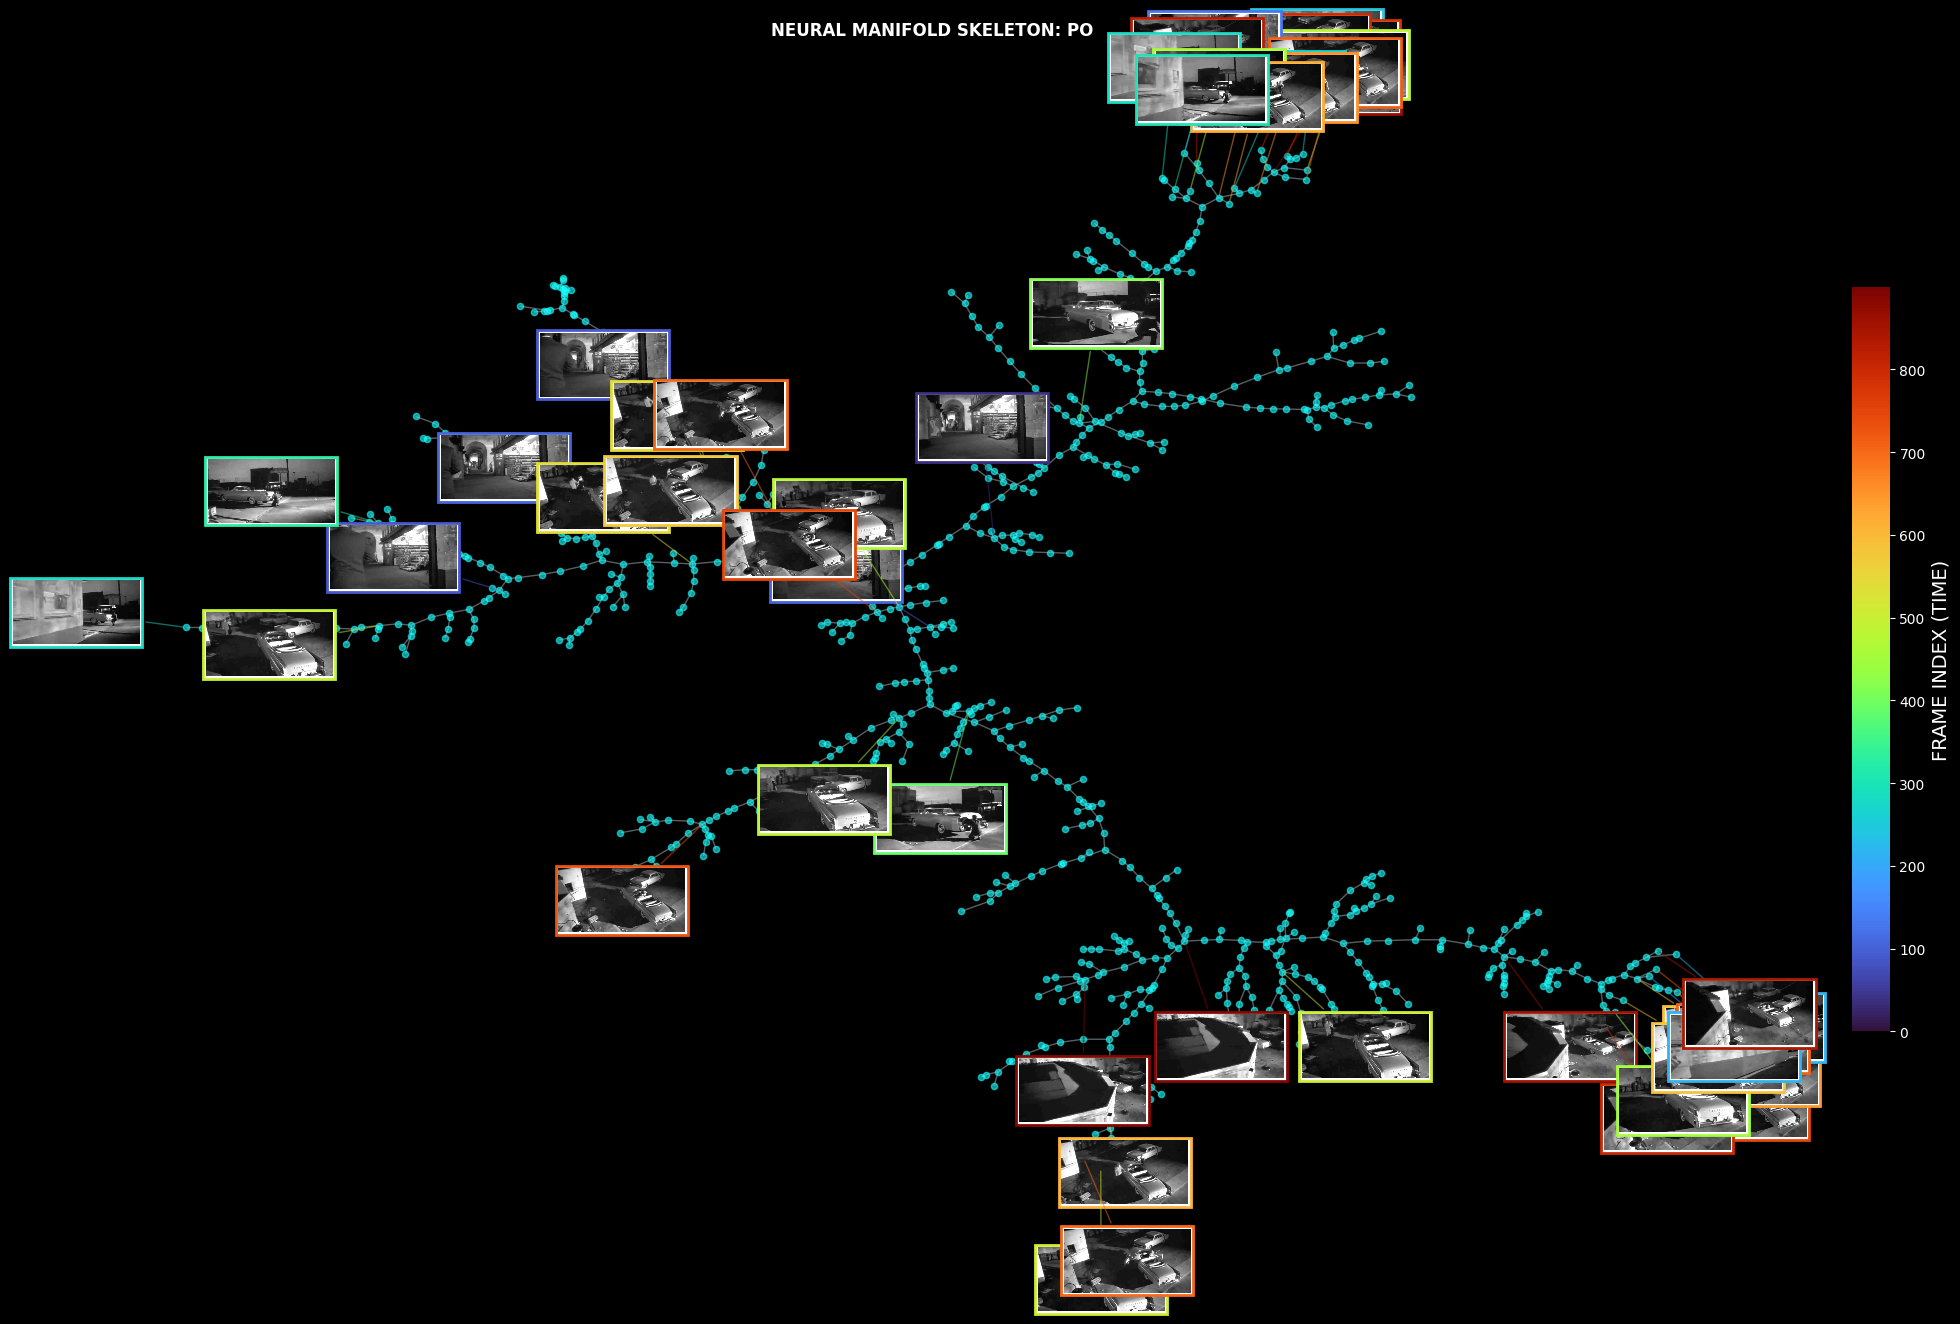

Finished analysis for PO

STARTING ANALYSIS FOR REGION: LP
Found 142 units in LP
Calculating spike counts...
Running PCA & UMAP...


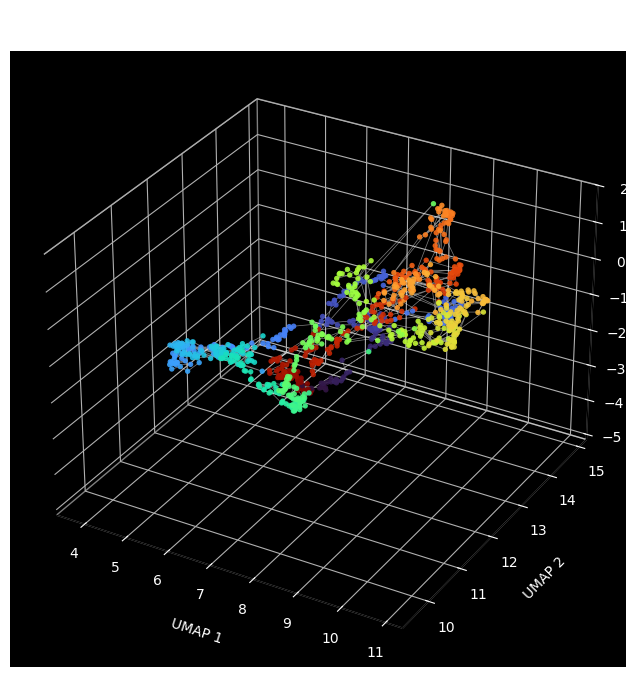

Running Persistent Homology...


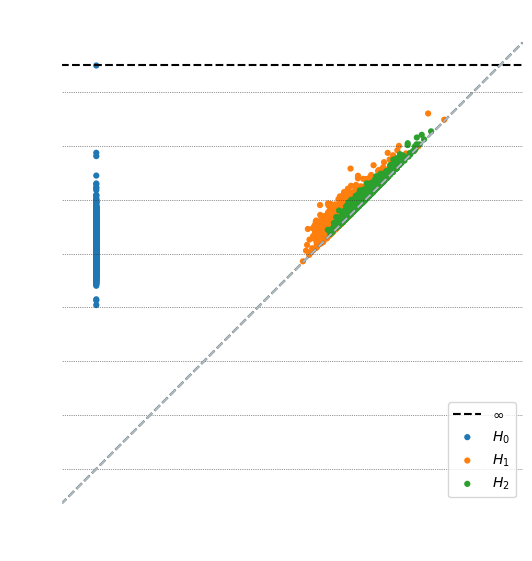

Building Transition Network...


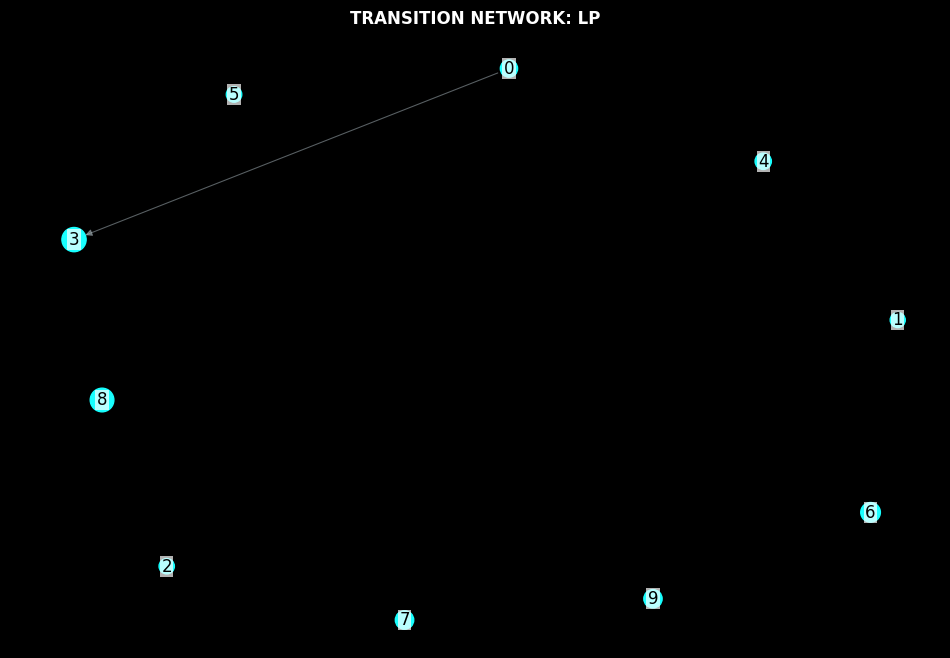

Building Spanning Tree & Visualizing...


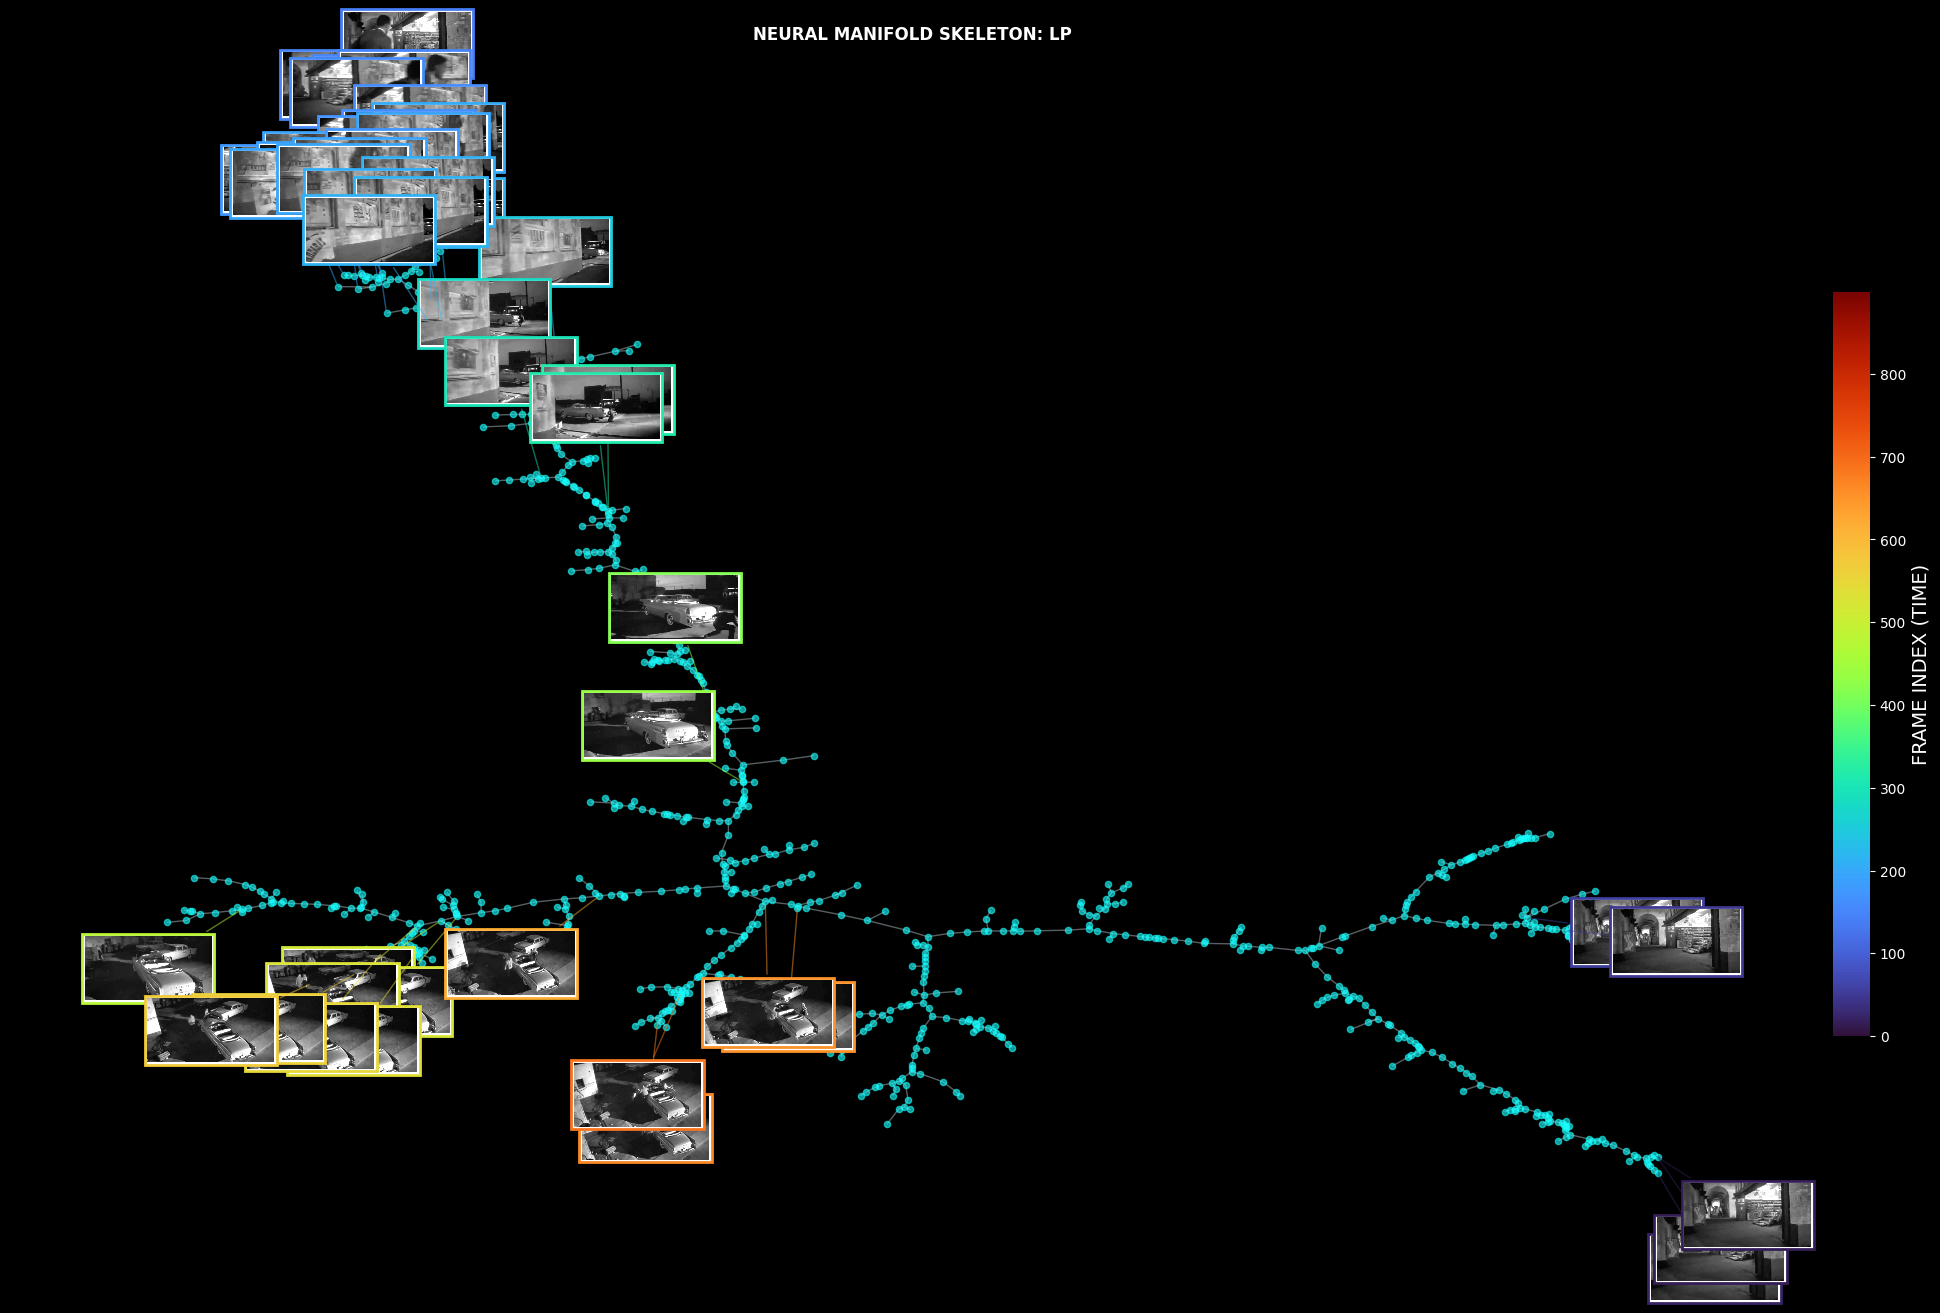

Finished analysis for LP

STARTING ANALYSIS FOR REGION: DG
Found 26 units in DG
Calculating spike counts...
Running PCA & UMAP...


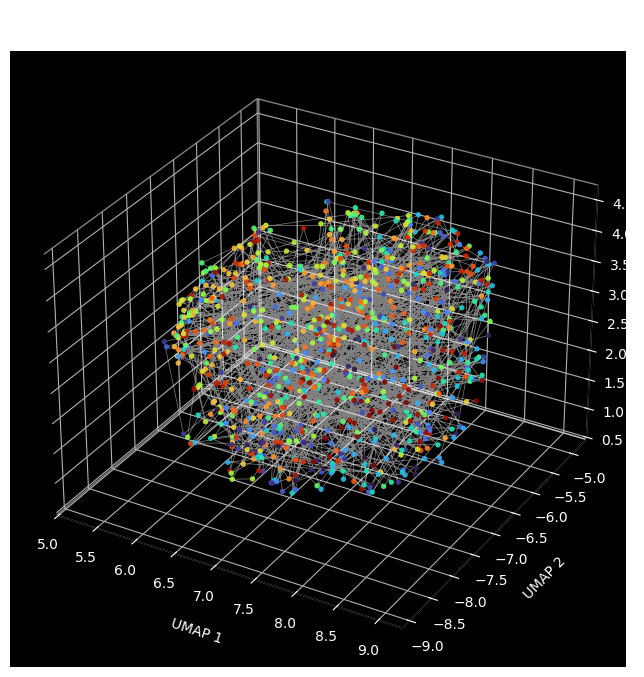

Running Persistent Homology...


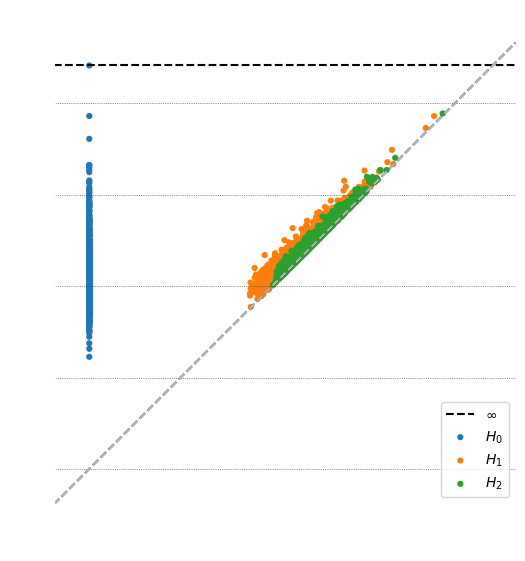

Building Transition Network...


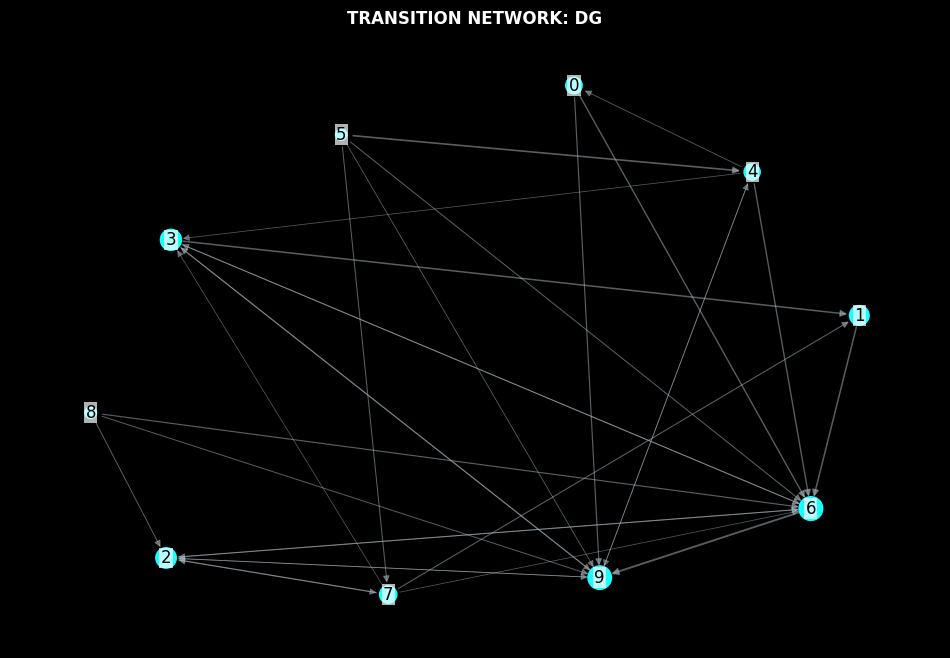

Building Spanning Tree & Visualizing...


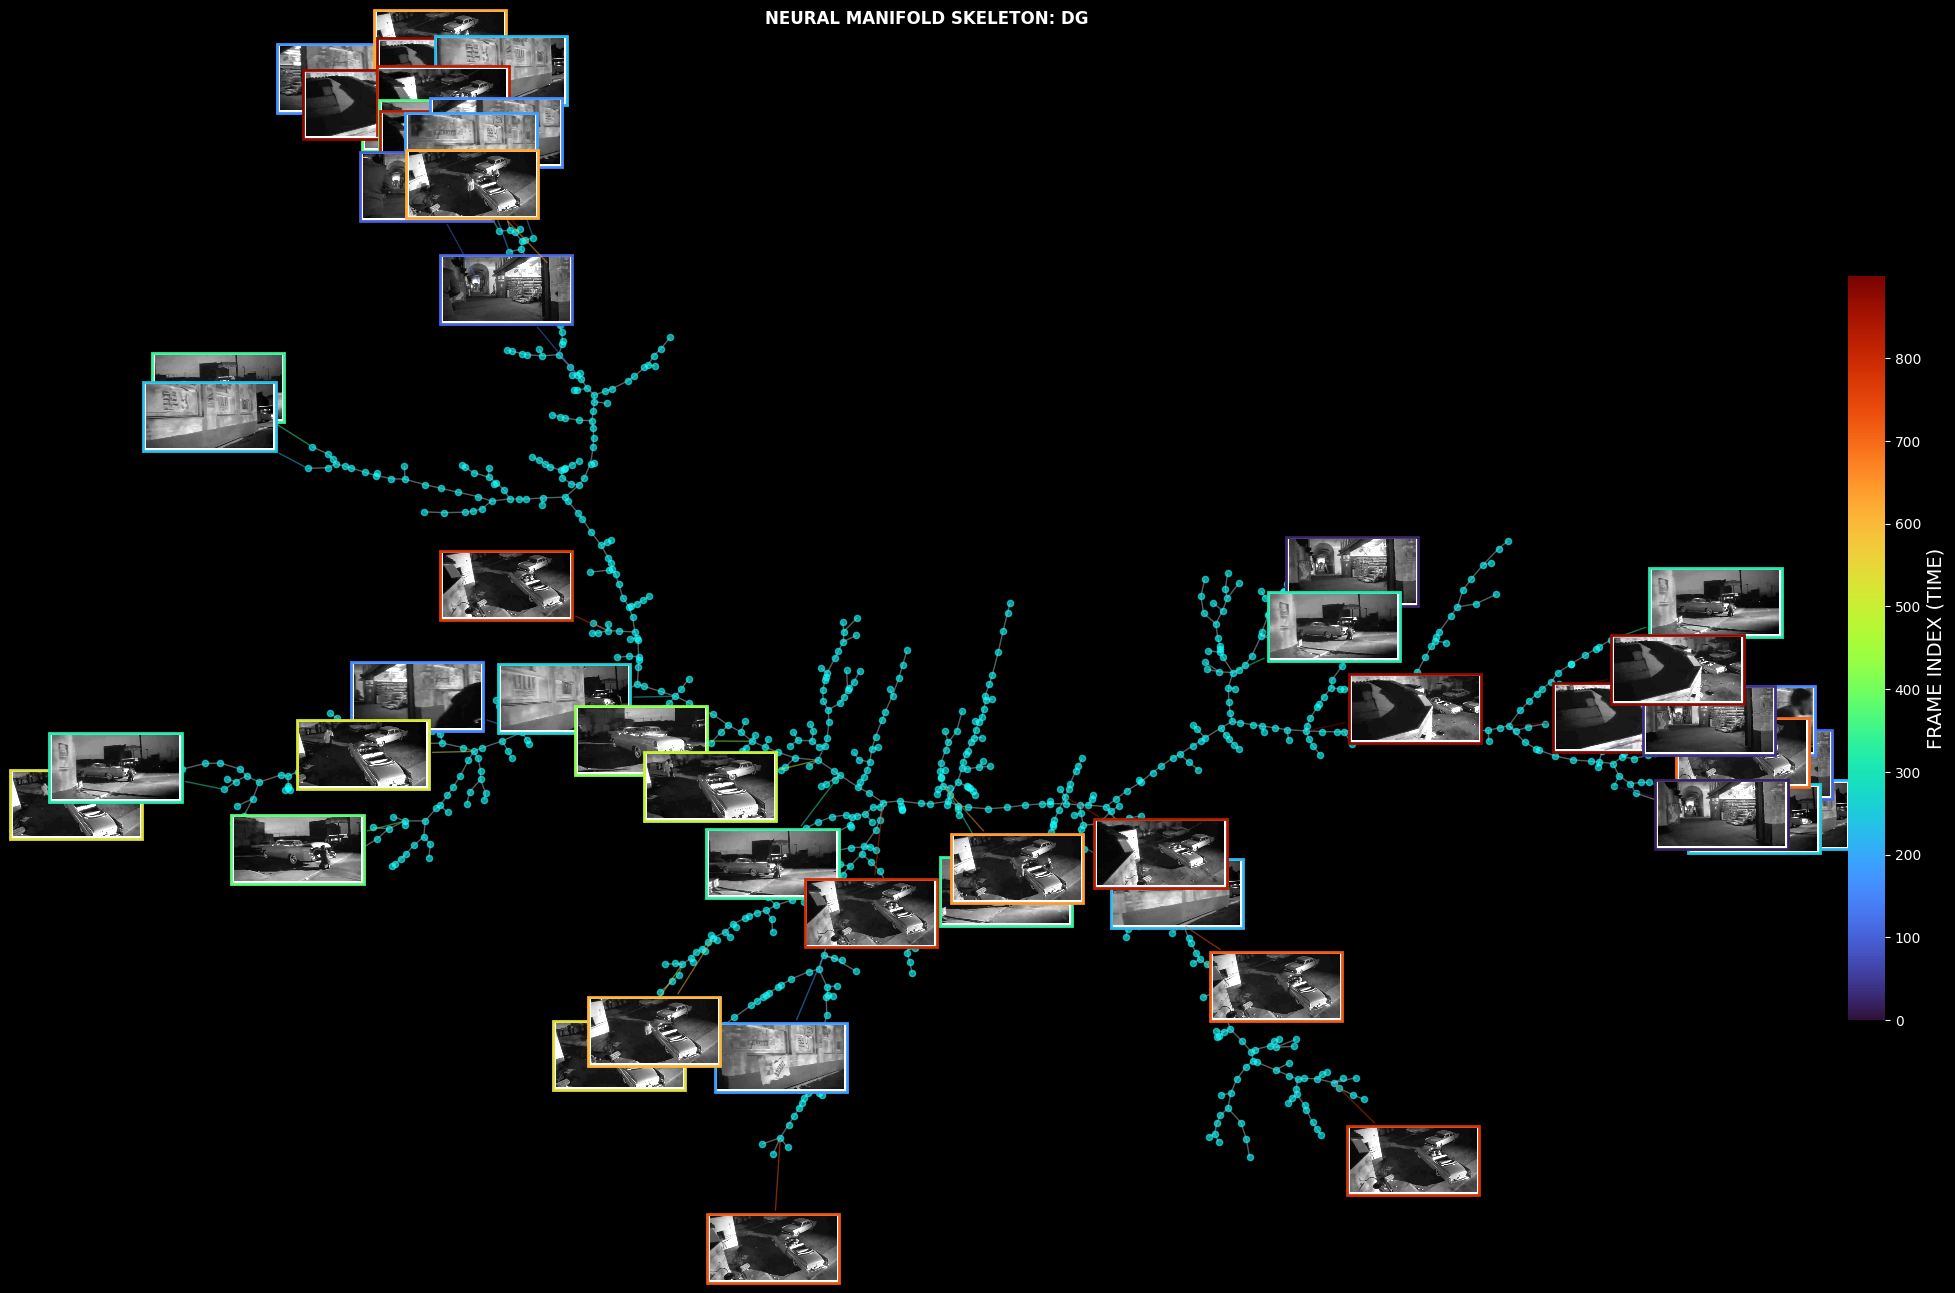

Finished analysis for DG

STARTING ANALYSIS FOR REGION: CA1
Found 113 units in CA1
Calculating spike counts...
Running PCA & UMAP...


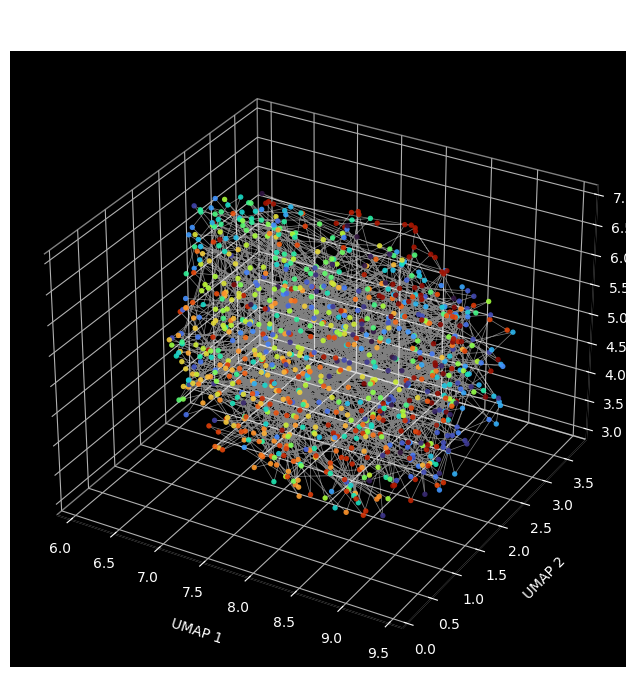

Running Persistent Homology...


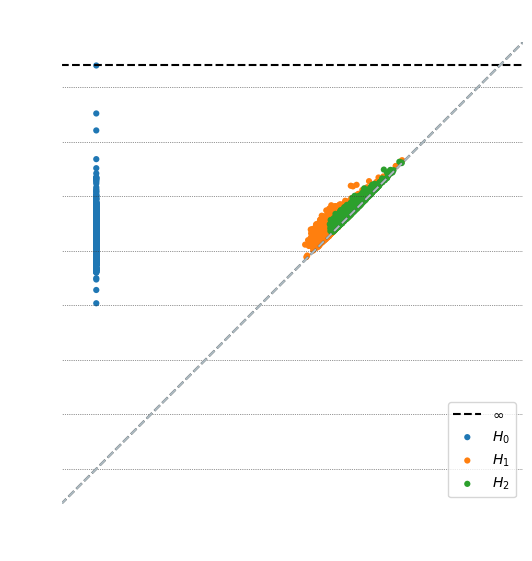

Building Transition Network...


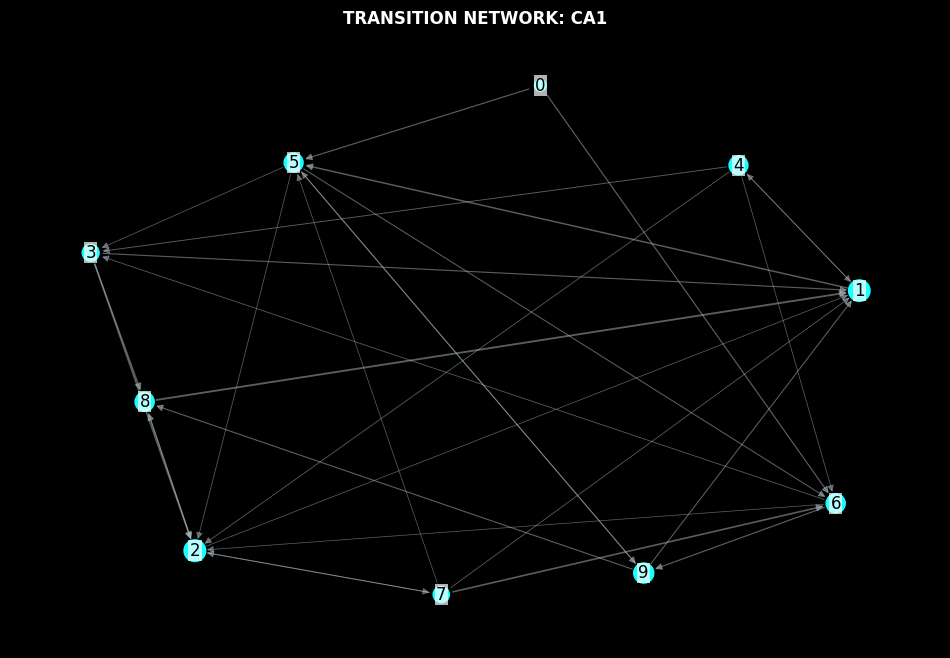

Building Spanning Tree & Visualizing...


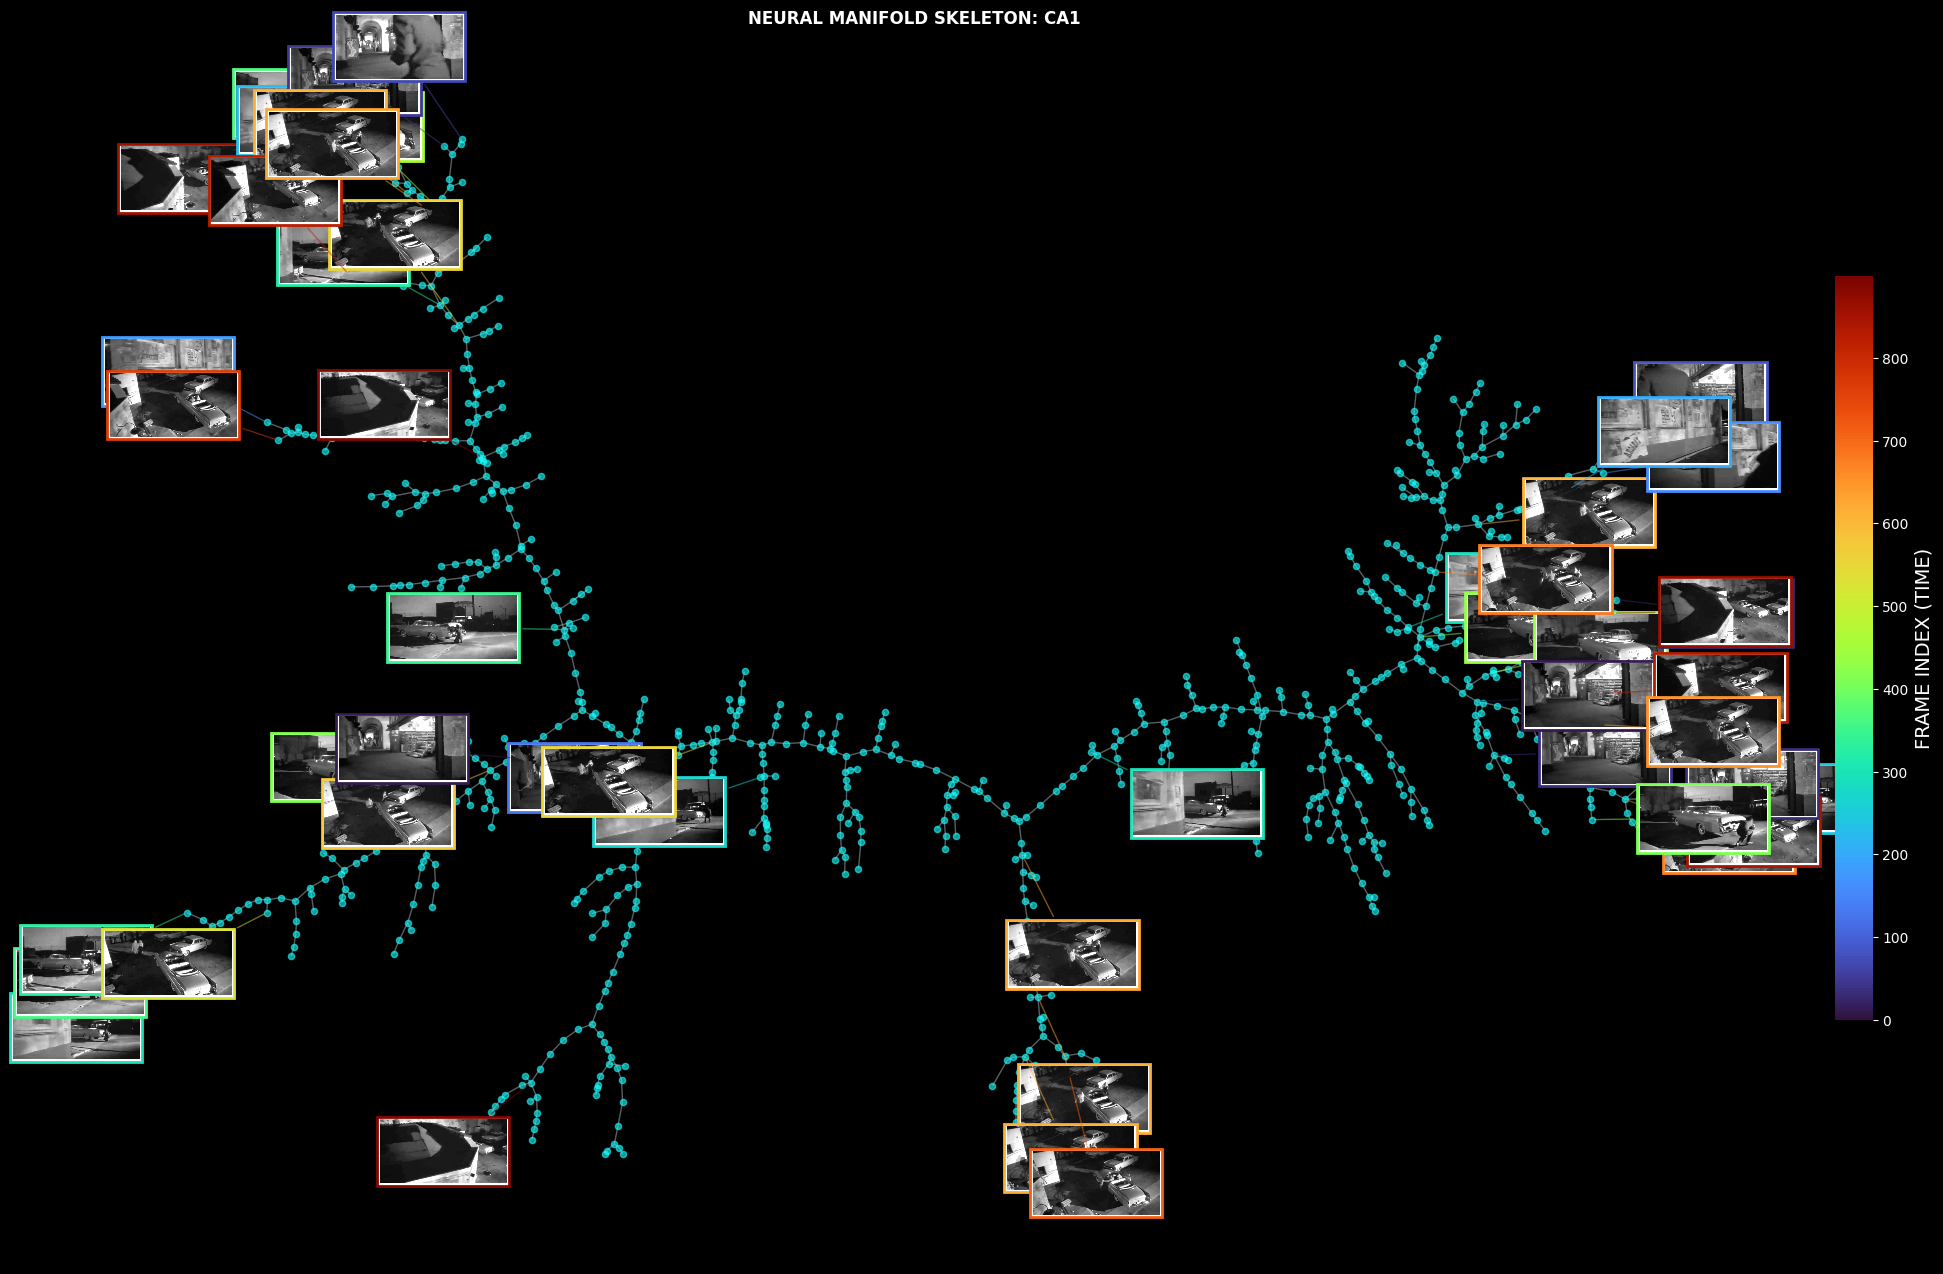

Finished analysis for CA1

STARTING ANALYSIS FOR REGION: VISam
Found 64 units in VISam
Calculating spike counts...
Running PCA & UMAP...


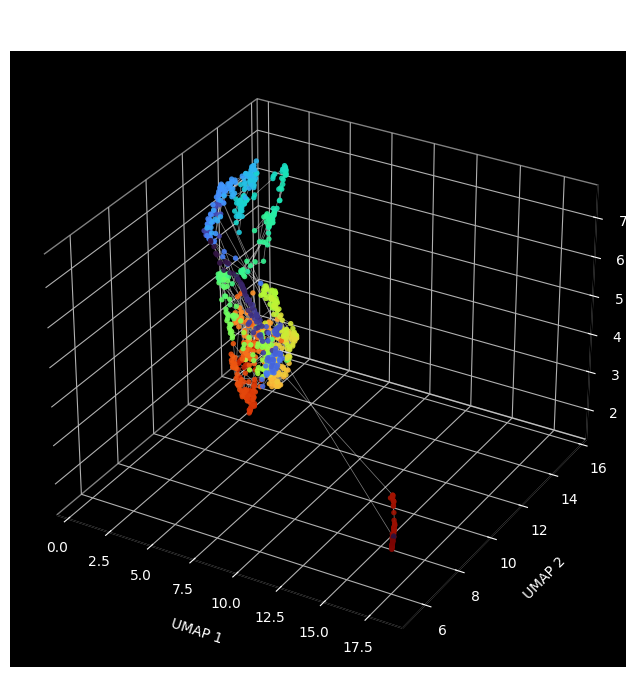

Running Persistent Homology...


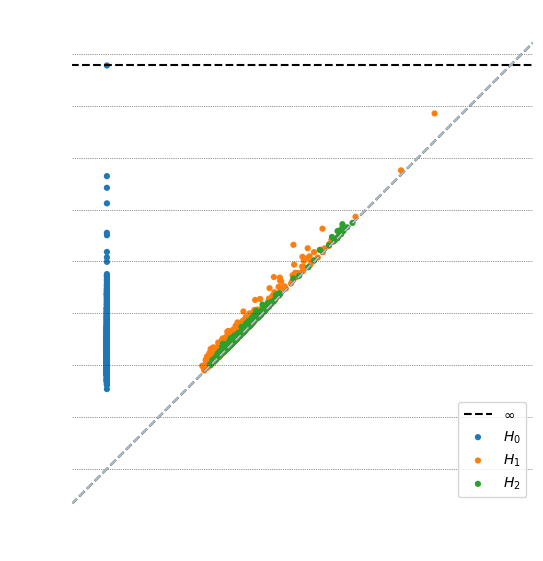

Building Transition Network...


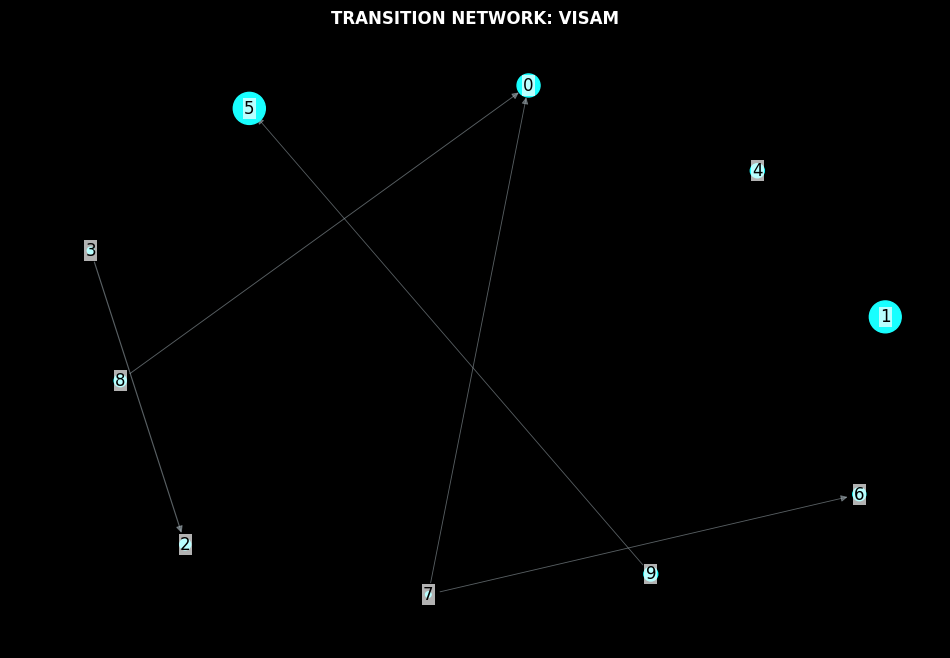

Building Spanning Tree & Visualizing...


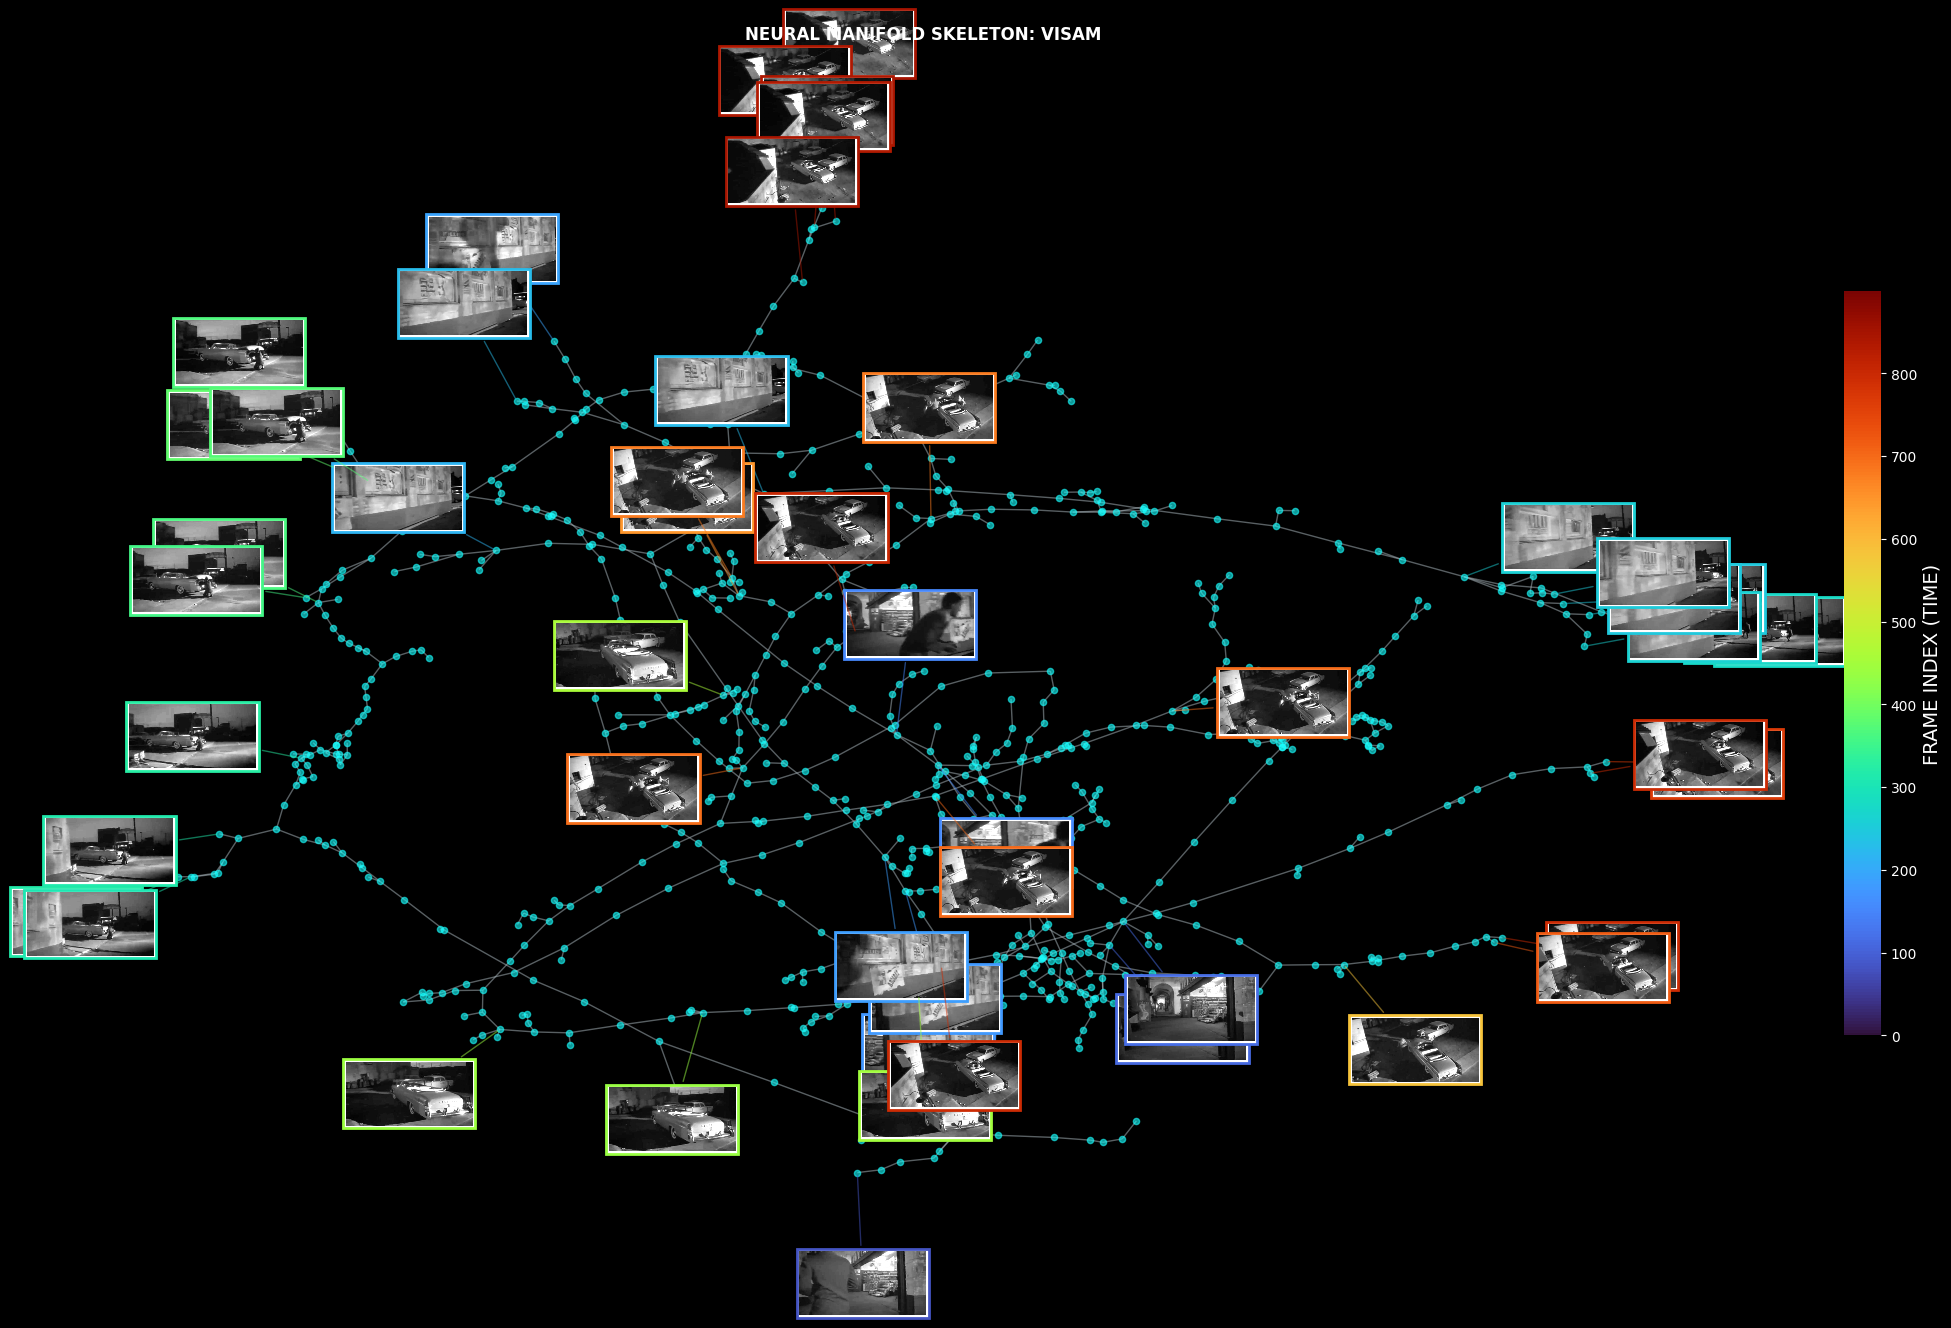

Finished analysis for VISam

STARTING ANALYSIS FOR REGION: LD
Found 1 units in LD
Skipping LD: Not enough units (<10).

STARTING ANALYSIS FOR REGION: VISpm
Found 64 units in VISpm
Calculating spike counts...
Running PCA & UMAP...


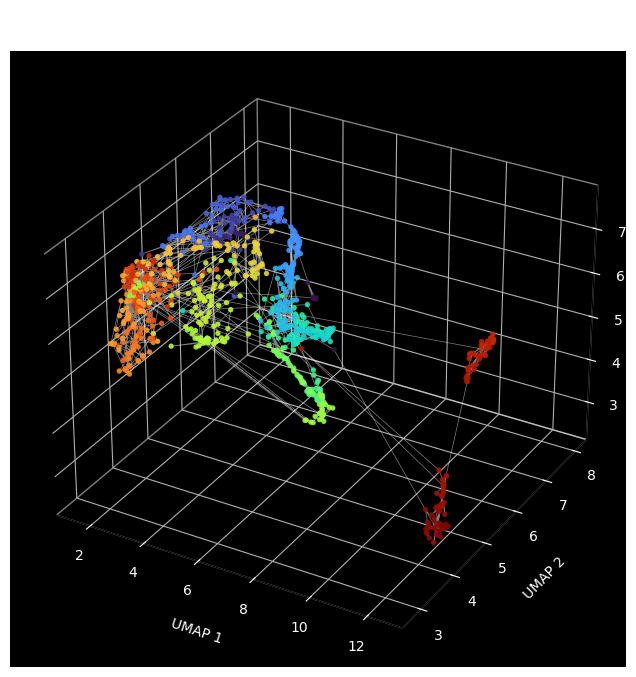

In [ ]:
# --- 4. Execute Iteration ---

# Get all unique regions in this session
all_regions = session.units["ecephys_structure_acronym"].unique()
print(f"Available Regions: {all_regions}")

# Filter out 'nan' or invalid regions if any
valid_regions = [r for r in all_regions if isinstance(r, str)]

# Run Pipeline for each region
for region in valid_regions:
    try:
        run_tda_pipeline(session, region, movie_template)
    except Exception as e:
        print(f"Error processing {region}: {e}")